# KVCache 워크로드 분석 → TensorMesh 클러스터 주입 → aiperf 프로파일링

**KCC 2026 튜토리얼 · Google Colab**

이 노트북은 다음 한 흐름을 끝까지 실습합니다.

1. **이해** — Mooncake / KVCache-in-the-Wild 논문의 워크로드를 trace 로 직접 만져봅니다.
2. **분석** — `dataset/` 의 실제 trace(`hash_ids` 기반)로 KVCache 재사용·prefix hit 비율·LRU 곡선을 계산합니다.
3. **합성** — 분석 결과를 그대로 모사한 *데이터 클러스터(합성 프롬프트 묶음)* 를 만듭니다.
4. **주입** — TensorMesh(LMCache enterprise) **OpenAI 호환 API** 로 클러스터를 보냅니다.
5. **측정** — 응답의 `usage.prompt_tokens_details.cached_tokens` 로 *실측 KVCache hit ratio* 를, **aiperf** 로 TTFT/지연/처리량을 프로파일합니다.
6. **결론** — 이론값(trace 분석) ↔ 실측값(TensorMesh)을 비교하고 논문의 주장과 연결합니다.

---

### 왜 이런 방식인가

vLLM 을 직접 띄우면 `/metrics` 에서 prefix cache hit 을 batch/online 으로 바로 볼 수 있습니다.
하지만 TensorMesh 는 **API 로만 노출**되므로 내부 지표에 직접 접근할 수 없습니다.
대신 두 가지 신호를 사용합니다.

| 신호 | 출처 | 의미 |
|---|---|---|
| `usage.prompt_tokens_details.cached_tokens` | 채팅 응답 JSON | 그 요청에서 **재사용된 prompt 토큰 수** (= 실측 KVCache hit) |
| **TTFT** (Time-To-First-Token) | 스트리밍 / aiperf | prefix 가 캐시되면 prefill 을 건너뛰어 TTFT 가 **떨어짐** |

> ⚠️ `serverless.tensormesh.ai` 는 공용 서버라 부하가 몰리면 `429 "Server is overloaded"` (retry-after) 를 줍니다.
> 이 노트북은 기본적으로 **concurrency=1 + 지수 backoff** 로 동작하며, 라이브 호출 수를 작게 유지합니다.


## 0. 환경 설정

Colab 에서 첫 셀부터 순서대로 실행하세요.

In [1]:
# 0-1. 패키지 설치 (Colab)
# aiperf 는 Python 3.10+ 필요. Colab 기본 런타임에서 동작합니다.
%pip install -q aiperf pandas numpy matplotlib requests tqdm
print("installed")

/home/hadry/lab/kcc2026-tutorial/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.
installed


In [2]:
# 0-2. 기본 import & 설정
import json, time, os, random, subprocess, glob
from collections import OrderedDict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- TensorMesh 접속 정보 ---
# 키는 절대 노트북에 하드코딩하지 마세요. .env (TENSORMESH_API_KEY) 에서 읽고,
# 없으면 입력창(getpass)으로 받습니다. (.env.example 을 .env 로 복사해 채우세요.)
try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True))          # 현재 작업폴더 기준으로 .env 탐색·로드
except ImportError:
    pass

TM_URL_BASE = os.environ.get("TENSORMESH_BASE_URL", "https://serverless.tensormesh.ai")  # aiperf 의 --url 에 사용
TM_API_V1   = TM_URL_BASE + "/v1"                  # 직접 호출용
TM_API_KEY  = os.environ.get("TENSORMESH_API_KEY", "")
if not TM_API_KEY:
    from getpass import getpass
    TM_API_KEY = getpass("TensorMesh API key (ak-...): ")

MODEL_QWEN = "Qwen/Qwen3.6-27B-FP8"     # 본 실습 주력 (저비용)
MODEL_KIMI = "moonshotai/Kimi-K2.6"     # 일부 시연용

pd.set_option("display.max_columns", 80); pd.set_option("display.width", 160)
print("ready. model =", MODEL_QWEN)

ready. model = Qwen/Qwen3.6-27B-FP8


In [3]:
# 0-3. 데이터셋 준비
# 로컬에 dataset/ 폴더가 있으면 그대로 사용하고, Colab 이면 업로드/마운트 안내.
DATA = Path("dataset")
EXPECTED = ["qwen_thinking_blksz_16.jsonl",
            "qwen_traceA_blksz_16.jsonl","qwen_traceB_blksz_16.jsonl",
            "kimi_conversation_trace.jsonl","kimi_toolagent_trace.jsonl"]

if not DATA.exists() or not any((DATA/f).exists() for f in EXPECTED):
    try:
        from google.colab import files  # Colab 환경
        print("dataset/ 가 없습니다. jsonl 파일들을 업로드하세요 (또는 Drive 마운트).")
        DATA.mkdir(exist_ok=True)
        up = files.upload()
        for name in up: os.replace(name, DATA/name)
    except Exception as e:
        print("로컬 실행: dataset/ 폴더에 trace jsonl 들을 두세요.", e)

print("dataset files:", sorted(p.name for p in DATA.glob('*.jsonl')) if DATA.exists() else "NONE")

dataset files: ['kimi_conversation_trace.jsonl', 'kimi_toolagent_trace.jsonl', 'qwen_thinking_blksz_16.jsonl', 'qwen_traceA_blksz_16.jsonl', 'qwen_traceB_blksz_16.jsonl']


## 1. 배경: 논문과 워크로드, 그리고 trace 포맷

수강 전제 논문 (직접 읽어오셨다는 가정):

- **Mooncake: A KVCache-centric Disaggregated Architecture for LLM Serving** — prefill/decode 를 분리하고, KVCache 를 GPU/CPU/SSD 에 걸친 **분산 KVCache pool** 로 관리해 *prefix 재사용* 을 극대화.
- **MOONCAKE: Trading More Storage for Less Computation** — KVCache 를 저장해두면 재계산(prefill) 을 건너뛸 수 있음. "스토리지를 더 써서 연산을 줄인다".
- **KVCache Cache in the Wild** — 대형 클라우드의 실제 트래픽에서 KVCache 재사용을 특성화: prefix 공유, **블록 인기도의 Zipf 분포**, **reuse distance**, 워크로드 카테고리별(코딩/대화/툴) 차이.

### trace 포맷 (핵심)

각 줄은 한 요청이며, 다음을 담습니다.

```json
{"timestamp": 0, "input_length": 6758, "output_length": 500, "hash_ids": [0, 1, 2, ...]}
```

- `hash_ids` = prompt 를 **블록 단위로 해싱한 prefix 해시 ID 열**. 앞선 모든 블록을 누적 해싱하므로,
  **두 요청의 `hash_ids` 가 앞에서부터 같다 = 같은 prefix 를 공유 = KVCache hit 가능**.
- 블록 크기는 데이터셋마다 다릅니다: **Kimi(Mooncake 원본) = 512 토큰**, **Qwen = 16 토큰** (파일명 `blksz_16`).
- `hash_id == 0` 은 보통 공통 system prompt 같은 **루트 블록**(거의 모든 요청이 공유)입니다.

### 제공 데이터셋

| 파일 | 모델/블록 | 워크로드 성격 |
|---|---|---|
| `kimi_conversation_trace.jsonl` | Kimi / 512 | 멀티턴 **대화** (Mooncake conversation) |
| `kimi_toolagent_trace.jsonl` | Kimi / 512 | **툴/에이전트** 호출 |
| `qwen_coder_blksz_16.jsonl` | Qwen / 16 | **코딩** 어시스턴트 |
| `qwen_thinking_blksz_16.jsonl` | Qwen / 16 | **추론(thinking)**, 긴 출력 |
| `qwen_traceA_blksz_16.jsonl` | Qwen / 16 | 혼합(text/image/search) |
| `qwen_traceB_blksz_16.jsonl` | Qwen / 16 | **API** 트래픽, 대량·짧은 출력 |

> 더 깊은 오프라인 분석(블록 수명, working set, KV 메모리 추정 등)은 함께 제공된
> `kvcache_trace_workload_analysis.ipynb` 를 참고하세요. 이 노트북은 그 결과를 **라이브 실험으로 연결**하는 데 집중합니다.


## 2. trace 로드 & KVCache 분석

이론적인(=무한 캐시 가정) prefix hit 비율과 유한 캐시(LRU) 곡선을 계산합니다.
이 값들이 뒤에서 합성 클러스터의 **목표치** 가 됩니다.

In [4]:
# 2-1. 로더 & 블록 크기 자동 감지
def load_trace(path, limit=None):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
                if limit and len(rows) >= limit:
                    break
    return rows

def detect_block_size(rows, sample=2000):
    ratios = [r["input_length"]/len(r["hash_ids"]) for r in rows[:sample] if r["hash_ids"]]
    med = float(np.median(ratios))
    for b in [16,32,64,128,256,512,1024]:
        if abs(med-b)/b < 0.25:
            return b, med
    return int(round(med)), med

In [5]:
# 2-2. 이론적 prefix hit (무한 캐시) + 요청별 분포
def sequential_history_hit(rows):
    seen=set(); hit_refs=0; total_refs=0; per_req=[]
    for r in rows:
        ids=r["hash_ids"]
        h=sum(1 for b in ids if b in seen)
        hit_refs+=h; total_refs+=len(ids)
        per_req.append(h/len(ids) if ids else np.nan)
        seen.update(ids)
    return (hit_refs/total_refs if total_refs else 0.0), per_req

# 2-3. 유한 캐시 LRU hit 곡선 (블록 단위)
def lru_curve(rows, capacities):
    out=[]
    for cap in capacities:
        cache=OrderedDict(); hits=misses=0
        for r in rows:
            for b in r["hash_ids"]:
                if b in cache:
                    hits+=1; cache.move_to_end(b)
                else:
                    misses+=1; cache[b]=None
                    if len(cache)>cap: cache.popitem(last=False)
        tot=hits+misses
        out.append({"capacity_blocks":cap, "hit_rate":hits/tot if tot else 0.0})
    return pd.DataFrame(out)

In [6]:
# 2-4. 한 데이터셋 분석 실행
TRACE_FILE = "qwen_traceA_blksz_16.jsonl"   # 바꿔가며 실행해보세요
rows = load_trace(DATA/TRACE_FILE)
BLOCK_SIZE, med = detect_block_size(rows)
hit_ratio, per_req = sequential_history_hit(rows)

inp=np.array([r["input_length"] for r in rows]); outp=np.array([r["output_length"] for r in rows])
nb =np.array([len(r["hash_ids"]) for r in rows])
print(f"[{TRACE_FILE}] requests={len(rows):,}  block_size≈{BLOCK_SIZE} (median ratio {med:.1f})")
print(f"input_len  p50/p90/p99 = {np.percentile(inp,[50,90,99]).round(0)}")
print(f"output_len p50/p90/p99 = {np.percentile(outp,[50,90,99]).round(0)}")
print(f"무한 캐시 prefix hit ratio = {hit_ratio:.3f}")
print(f"요청별 hit ratio p50/p90 = {np.nanpercentile(per_req,[50,90]).round(3)}")

[qwen_traceA_blksz_16.jsonl] requests=43,058  block_size≈16 (median ratio 15.9)
input_len  p50/p90/p99 = [ 1046.  6436. 14365.]
output_len p50/p90/p99 = [ 376.  808. 1641.]
무한 캐시 prefix hit ratio = 0.594
요청별 hit ratio p50/p90 = [0.681 0.958]


,capacity_blocks,hit_rate
0,64,0.025205
1,256,0.072433
2,1024,0.128639
3,4096,0.152303
4,16384,0.177621
5,65536,0.318002


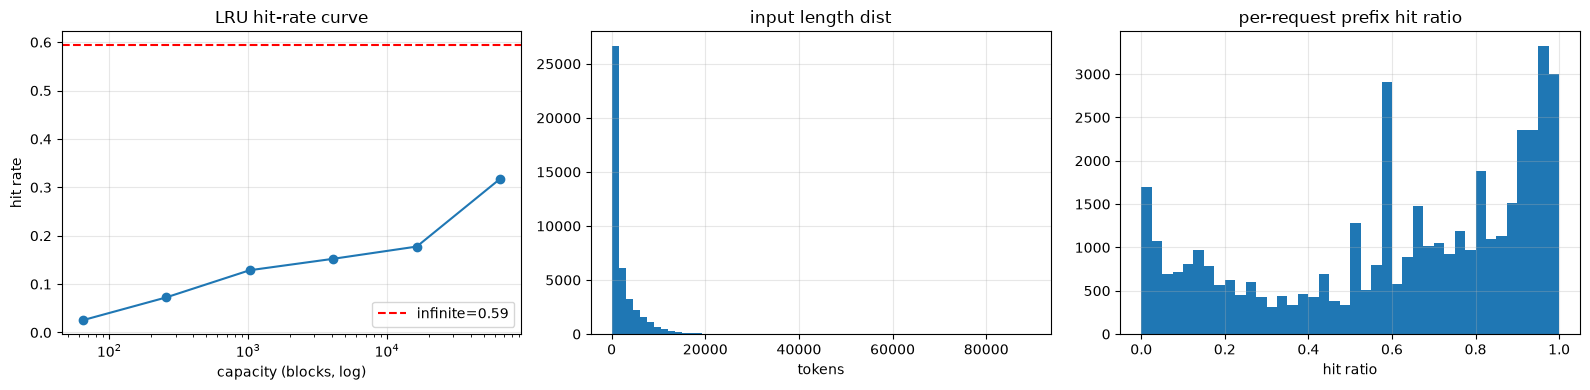

In [7]:
# 2-5. LRU 곡선 & 분포 시각화
caps=[64,256,1024,4096,16384,65536]
lru_df=lru_curve(rows,caps)
display(lru_df)

fig,ax=plt.subplots(1,3,figsize=(16,4))
ax[0].plot(lru_df["capacity_blocks"],lru_df["hit_rate"],marker="o"); ax[0].set_xscale("log")
ax[0].axhline(hit_ratio,ls="--",c="r",label=f"infinite={hit_ratio:.2f}")
ax[0].set_title("LRU hit-rate curve"); ax[0].set_xlabel("capacity (blocks, log)"); ax[0].set_ylabel("hit rate"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].hist(inp,bins=60); ax[1].set_title("input length dist"); ax[1].set_xlabel("tokens"); ax[1].grid(alpha=.3)
ax[2].hist([x for x in per_req if not np.isnan(x)],bins=40); ax[2].set_title("per-request prefix hit ratio"); ax[2].set_xlabel("hit ratio"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

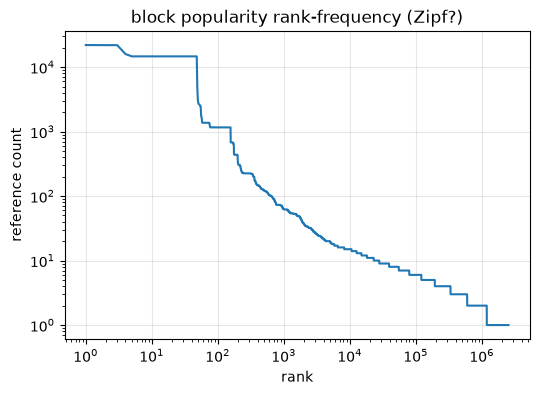

,dataset,block_size,sample_reqs,prefix_hit_ratio
0,qwen_thinking_blksz_16.jsonl,16,10812,0.462
1,qwen_traceA_blksz_16.jsonl,16,20000,0.545
2,qwen_traceB_blksz_16.jsonl,16,20000,0.547
3,kimi_conversation_trace.jsonl,512,12031,0.366
4,kimi_toolagent_trace.jsonl,512,20000,0.548


In [8]:
# 2-6. 블록 인기도 (Zipf) & 워크로드 비교
from collections import Counter
cnt=Counter(b for r in rows for b in r["hash_ids"])
freq=np.array(sorted(cnt.values(),reverse=True))
plt.figure(figsize=(6,4))
plt.loglog(np.arange(1,len(freq)+1),freq)
plt.title("block popularity rank-frequency (Zipf?)"); plt.xlabel("rank"); plt.ylabel("reference count"); plt.grid(alpha=.3); plt.show()

# 여러 데이터셋의 이론 hit ratio 한눈에 비교 (대용량은 앞부분만 샘플)
summary=[]
for fn in EXPECTED:
    p=DATA/fn
    if not p.exists(): continue
    rws=load_trace(p, limit=20000)
    bs,_=detect_block_size(rws); hr,_=sequential_history_hit(rws)
    summary.append({"dataset":fn,"block_size":bs,"sample_reqs":len(rws),"prefix_hit_ratio":round(hr,3)})
display(pd.DataFrame(summary))

## 3. 분석 → 합성 데이터 클러스터 설계

핵심 아이디어: **`hash_id` 하나를 결정적(deterministic) 텍스트 블록 하나로 매핑**합니다.

- 같은 `hash_id` → 항상 **똑같은 텍스트** → 서버에서 **진짜 prefix cache hit** 발생
- 다른 `hash_id` → 서로 다른 텍스트 → cache miss

이 매핑 위에서 두 종류의 클러스터를 만듭니다.

- **(A) trace 모사 클러스터** — 실제 trace 의 `hash_ids` 구조를 그대로 복원. → 이론 hit ↔ 실측 `cached_tokens` 직접 비교.
- **(B) 파라메트릭 클러스터** — 공유 prefix 비율 `f` 를 0/0.3/0.6/0.9 로 직접 조절. → cache hit 이 TTFT/처리량에 주는 영향을 통제 실험.

> 참고: 우리가 만든 "블록"은 단어 기준이라 서버 토크나이저의 16/512-토큰 경계와 정확히 일치하지 않습니다.
> 따라서 목표 공유비율 `f` 와 실측 `cached_tokens/prompt_tokens` 는 **정확히 같지 않고 비례**합니다. (그게 정상이고, 그래서 실측을 따로 봅니다.)

In [9]:
# 3-1. hash_id -> 결정적 블록 텍스트
_WORDS=("alpha bravo charlie delta echo foxtrot golf hotel india juliet kilo lima mike "
        "november oscar papa quebec romeo sierra tango uniform victor whiskey xray yankee "
        "zulu lorem ipsum dolor sit amet consectetur adipiscing elit").split()

def block_text(hash_id, block_size):
    rng=random.Random((hash_id*2654435761) & 0xffffffff)
    return f"<b{hash_id}>" + " ".join(_WORDS[rng.randrange(len(_WORDS))] for _ in range(block_size))

def build_prompt_from_hashids(hash_ids, block_size):
    return "\n".join(block_text(h, block_size) for h in hash_ids)

In [10]:
# 3-2. (A) trace 모사 클러스터
def build_trace_mimic_cluster(rows, block_size, n, max_out=16):
    out=[]
    for r in rows[:n]:
        out.append({"text_input": build_prompt_from_hashids(r["hash_ids"], block_size),
                    "output_length": min(int(r["output_length"]), max_out),
                    "n_blocks": len(r["hash_ids"]),
                    "hash_ids": r["hash_ids"]})
    return out

# 3-3. (B) 파라메트릭 클러스터 (공유 prefix 비율 f 통제)
def build_parametric_cluster(n_requests, total_blocks, shared_frac, block_size, base_id):
    n_shared=int(round(shared_frac*total_blocks))
    shared_ids=list(range(base_id, base_id+n_shared))
    out=[]; uid=base_id+100_000
    for _ in range(n_requests):
        uniq=list(range(uid, uid+(total_blocks-n_shared))); uid+=(total_blocks-n_shared)+1
        out.append({"text_input": build_prompt_from_hashids(shared_ids+uniq, block_size),
                    "output_length":16, "target_shared_frac":shared_frac, "n_blocks":total_blocks})
    return out

# 결정성 검증: [0,1,2] 와 [0,1,9] 는 블록 0,1 만큼 prefix 가 같아야 함
a=build_prompt_from_hashids([0,1,2],BLOCK_SIZE); b=build_prompt_from_hashids([0,1,9],BLOCK_SIZE)
print("공통 prefix 글자수:", len(os.path.commonprefix([a,b])), "/ a 길이:", len(a))
mimic=build_trace_mimic_cluster(rows,BLOCK_SIZE,3)
print("trace-mimic[0] blocks:",mimic[0]['n_blocks']," head:",mimic[0]['text_input'][:70].replace(chr(10),' '))

공통 prefix 글자수: 229 / a 길이: 334
trace-mimic[0] blocks: 50  head: <b0>yankee lorem charlie quebec adipiscing consectetur zulu tango amet


## 4. TensorMesh 라이브 호출 + cold vs warm 단건 데모

스트리밍으로 **TTFT** 를 재고, 응답 `usage` 에서 **`cached_tokens`** 를 추출하는 클라이언트입니다.
`429` 는 `retry-after` 를 존중하며 지수 backoff 합니다.

> Qwen3.6 은 **reasoning 모델** 이라 첫 토큰이 `delta.reasoning` 으로 옵니다(아래 코드가 처리).

In [11]:
# 4-1. 라이브 클라이언트 (스트리밍 / 429 backoff / TTFT / cached_tokens)
import urllib.request, urllib.error

def chat_stream(text, model=MODEL_QWEN, max_tokens=16, temperature=0.0, retries=8,
                base_url=TM_API_V1, key=None):
    key=key or TM_API_KEY
    payload={"model":model,"max_tokens":max_tokens,"temperature":temperature,"stream":True,
             "stream_options":{"include_usage":True},
             "messages":[{"role":"user","content":text}]}
    url=base_url.rstrip("/")+"/chat/completions"
    for attempt in range(retries):
        req=urllib.request.Request(url, data=json.dumps(payload).encode(),
            headers={"Authorization":f"Bearer {key}","Content-Type":"application/json"})
        try:
            t0=time.time(); ttft=None; usage=None
            resp=urllib.request.urlopen(req, timeout=180)
            for raw in resp:
                line=raw.decode().strip()
                if not line.startswith("data:"): continue
                d=line[5:].strip()
                if d=="[DONE]": break
                j=json.loads(d)
                if j.get("usage"): usage=j["usage"]
                ch=j.get("choices") or []
                if ch and ttft is None:
                    dl=ch[0].get("delta",{})
                    if dl.get("content") or dl.get("reasoning") or dl.get("reasoning_content"):
                        ttft=time.time()-t0
            lat=time.time()-t0
            pd_=(usage or {}).get("prompt_tokens_details") or {}
            cached=pd_.get("cached_tokens") or 0          # null -> 0
            pt=(usage or {}).get("prompt_tokens")
            return {"ok":True,"ttft":ttft,"latency":lat,"prompt_tokens":pt,
                    "cached_tokens":cached,"hit_ratio":(cached/pt) if pt else None}
        except urllib.error.HTTPError as e:
            if e.code==429:
                wait=int(e.headers.get("retry-after","5"))+attempt*2
                print(f"    429 → {wait}s 대기"); time.sleep(wait); continue
            return {"ok":False,"error":f"HTTP {e.code}: {e.read().decode()[:120]}"}
        except Exception as e:
            return {"ok":False,"error":str(e)}
    return {"ok":False,"error":"max retries (429)"}

In [12]:
# 4-2. cold vs warm 단건 데모
# 처음 본 prefix(cold) -> 같은 prefix 재요청(warm) 시 cached_tokens 증가 & TTFT 감소 기대
demo_cluster=build_parametric_cluster(1, total_blocks=60, shared_frac=1.0, block_size=BLOCK_SIZE,
                                       base_id=random.randint(10_000_000, 90_000_000))
prefix_text=demo_cluster[0]["text_input"]

print("[COLD]"); c=chat_stream(prefix_text+"\n질문: 한 단어로 요약?", max_tokens=16); print("  ",c)
time.sleep(4)
print("[WARM]"); w=chat_stream(prefix_text+"\n질문: 다른 한 단어로?", max_tokens=16); print("  ",w)
print(f"\n→ cached_tokens: {c.get('cached_tokens')} → {w.get('cached_tokens')}")
print(f"→ TTFT(s):       {c.get('ttft') and round(c['ttft'],3)} → {w.get('ttft') and round(w['ttft'],3)}")

[COLD]


    429 → 5s 대기


    429 → 7s 대기


    429 → 9s 대기


    429 → 11s 대기


    429 → 13s 대기


    429 → 15s 대기


   {'ok': True, 'ttft': 1.0254464149475098, 'latency': 1.3548662662506104, 'prompt_tokens': 2037, 'cached_tokens': 0, 'hit_ratio': 0.0}


[WARM]


   {'ok': True, 'ttft': 0.7354786396026611, 'latency': 1.0646593570709229, 'prompt_tokens': 2037, 'cached_tokens': 1568, 'hit_ratio': 0.7697594501718213}

→ cached_tokens: 0 → 1568
→ TTFT(s):       1.025 → 0.735


In [13]:
# 4-3. Kimi-K2.6 도 동일 인터페이스로 동작 (시연용 1회)
k=chat_stream("Explain prefix caching in one sentence.", model=MODEL_KIMI, max_tokens=32)
print("Kimi:", k)

Kimi: {'ok': True, 'ttft': 0.7229039669036865, 'latency': 1.138519525527954, 'prompt_tokens': 15, 'cached_tokens': 0, 'hit_ratio': 0.0}


## 5. 클러스터 리플레이 → 실측 KVCache hit ratio

낮은 동시성으로 클러스터를 순차 재생하며 요청별 `cached_tokens` 와 TTFT 를 모읍니다.

In [14]:
# 5-1. 리플레이 헬퍼 (순차, backoff, 요청 간 간격)
def replay_cluster(cluster, model=MODEL_QWEN, gap=3.0, verbose=True):
    res=[]
    for i,item in enumerate(cluster):
        r=chat_stream(item["text_input"], model=model, max_tokens=item.get("output_length",16))
        r["idx"]=i; r["target_shared_frac"]=item.get("target_shared_frac")
        res.append(r)
        if verbose:
            print(f"  req{i}: ok={r['ok']} ttft={r.get('ttft') and round(r['ttft'],3)} "
                  f"prompt={r.get('prompt_tokens')} cached={r.get('cached_tokens')} "
                  f"hit={r.get('hit_ratio') and round(r['hit_ratio'],3)}")
        time.sleep(gap)
    return [r for r in res if r.get("ok")]

--- shared_frac = 0.0 ---


    429 → 5s 대기


    429 → 7s 대기


  req0: ok=True ttft=0.962 prompt=2055 cached=0 hit=0.0


    429 → 5s 대기


...

    429 → 7s 대기


    429 → 9s 대기


  req1: ok=True ttft=0.702 prompt=2043 cached=1568 hit=0.767


  req2: ok=True ttft=0.702 prompt=2046 cached=1568 hit=0.766


,target_f,measured_hit,ttft_mean
0,0.0,0.000000,0.950737
1,0.3,0.000000,0.950969
2,0.6,0.000000,0.997922
3,0.9,0.766936,0.701896


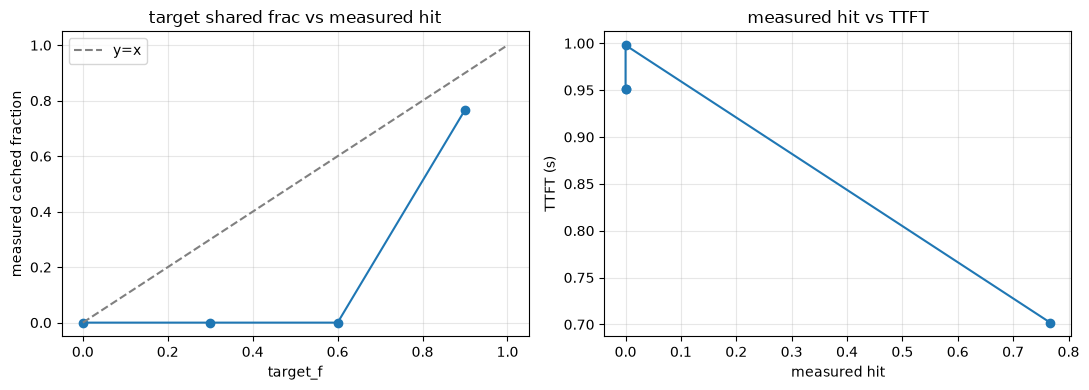

In [15]:
# 5-2. (B) 파라메트릭 스윕: 목표 공유비율 f vs 실측 cached fraction
sweep=[]
for f in [0.0, 0.3, 0.6, 0.9]:
    print(f"--- shared_frac = {f} ---")
    cl=build_parametric_cluster(3, total_blocks=60, shared_frac=f, block_size=BLOCK_SIZE,
                                base_id=random.randint(10_000_000, 90_000_000))
    rs=replay_cluster(cl, gap=4.0)
    warm=[r for r in rs if r["idx"]>0]                  # 첫 요청은 cold 라 제외
    if warm:
        sweep.append({"target_f":f,
                      "measured_hit":np.mean([r["hit_ratio"] for r in warm]),
                      "ttft_mean":np.mean([r["ttft"] for r in warm if r["ttft"]])})
sweep_df=pd.DataFrame(sweep); display(sweep_df)

if len(sweep_df):
    fig,ax=plt.subplots(1,2,figsize=(11,4))
    ax[0].plot(sweep_df["target_f"],sweep_df["measured_hit"],marker="o")
    ax[0].plot([0,1],[0,1],ls="--",c="gray",label="y=x")
    ax[0].set_title("target shared frac vs measured hit"); ax[0].set_xlabel("target_f"); ax[0].set_ylabel("measured cached fraction"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(sweep_df["measured_hit"],sweep_df["ttft_mean"],marker="o")
    ax[1].set_title("measured hit vs TTFT"); ax[1].set_xlabel("measured hit"); ax[1].set_ylabel("TTFT (s)"); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

In [16]:
# 5-3. (A) trace 모사: 이론 hit ↔ 실측 hit
# 실제 trace 앞부분을 복원해 재생. (공유 루트블록 hash_id=0 덕에 cached_tokens 가 잡힘)
N=6
mimic=build_trace_mimic_cluster(rows, BLOCK_SIZE, N)
print(f"trace 모사 {N}건 재생:")
rs=replay_cluster(mimic, gap=4.0)
theory_hit,_=sequential_history_hit(rows[:N])
meas=[r["hit_ratio"] for r in rs if r["idx"]>0 and r["hit_ratio"] is not None]
print(f"\n이론(무한캐시, 앞 {N}건) prefix hit ≈ {theory_hit:.3f}")
print(f"실측 평균 cached fraction      ≈ {np.mean(meas):.3f}" if meas else "실측 hit 데이터 부족")

trace 모사 6건 재생:


    429 → 5s 대기


  req0: ok=True ttft=0.859 prompt=1385 cached=0 hit=0.0


    429 → 5s 대기


  req1: ok=True ttft=0.954 prompt=674 cached=0 hit=0.0


...

  req3: ok=True ttft=0.77 prompt=650 cached=0 hit=0.0


    429 → 5s 대기


  req4: ok=True ttft=0.731 prompt=1325 cached=784 hit=0.592


  req5: ok=True ttft=0.755 prompt=1417 cached=784 hit=0.553



이론(무한캐시, 앞 6건) prefix hit ≈ 0.125
실측 평균 cached fraction      ≈ 0.234


## 6. aiperf 로 프로파일링

[aiperf](https://github.com/ai-dynamo/aiperf) 는 OpenAI 호환 엔드포인트를 부하·계측하는 도구로,
우리 trace 와 **동일한 `mooncake_trace` 포맷**을 기본 지원합니다.

- 인증: `--api-key` 가 자동으로 `Authorization: Bearer <key>` 헤더를 붙입니다. (또는 `-H "Header:Value"`)
- 토크나이저: 대상 모델 토크나이저가 HF 에 없으므로 `--tokenizer builtin`(오프라인) 사용.
- 산출물: `artifacts/<model>-openai-chat-concurrencyN/profile_export_aiperf.json` 에 TTFT/지연/처리량 분위수 저장.

> 공용 서버라 `429` 가 섞일 수 있습니다. `--concurrency 1`, 작은 `--request-count` 로 시작하세요.

In [17]:
# 6-1. aiperf 실행 & 결과 파싱 헬퍼
# 공용 엔드포인트는 요청이 몰리면 429("overloaded") 를 뱉습니다. aiperf 는 429 를 재시도하지 않으므로,
#   concurrency 로 연속 발사하면 버스트가 전부 429 → 유효 레코드 0 이 되기 쉽습니다.
# 따라서 --request-rate 로 요청 간격을 벌려(예: 0.25 req/s = 4초에 1건) 429 를 줄입니다.
# 또 3중 시간제한(요청별/벤치마크/subprocess)으로 절대 멈추지 않게 합니다.
# 결과는 --profile-export-prefix 로 지정한 <prefix>.json (avg/p50/p99 스키마) 에서 읽습니다.
def run_aiperf(input_file, dataset_type="mooncake_trace", model=MODEL_QWEN,
               request_rate=0.25, request_count=6, prefix="run",
               benchmark_duration=120, request_timeout=45, hard_timeout=200, extra=None):
    cmd=["aiperf","profile","--model",model,"--url",TM_URL_BASE,
         "--endpoint-type","chat","--endpoint","/v1/chat/completions",
         "--streaming","--api-key",TM_API_KEY,
         "--input-file",input_file,"--custom-dataset-type",dataset_type,
         "--no-fixed-schedule","--request-rate",str(request_rate),
         "--request-count",str(request_count),
         "--benchmark-duration",str(benchmark_duration),"--benchmark-grace-period","20",
         "--request-timeout-seconds",str(request_timeout),
         "--tokenizer","builtin","--extra-inputs","temperature:0.0",
         "--profile-export-prefix",prefix]
    if extra: cmd+=extra
    print(">> aiperf", input_file, f"(rc={request_count}, rate={request_rate}/s)")
    try:
        subprocess.run(cmd, check=False, timeout=hard_timeout)
    except subprocess.TimeoutExpired:
        print("   (subprocess hard_timeout 도달 → 종료, 부분 결과 파싱 시도)")
    files=sorted(glob.glob(f"artifacts/**/{prefix}.json",recursive=True), key=os.path.getmtime)
    if not files:
        return {"file":None,"error":"유효 레코드 0 (전부 429) — 엔드포인트 한가할 때 재시도",
                "ttft_avg":None,"ttft_p50":None,"ttft_p99":None,
                "req_latency_avg":None,"req_throughput":None,"valid":0,"errors":None}
    d=json.load(open(files[-1]))
    def g(m,s="avg"): return (d.get(m) or {}).get(s)
    return {"file":files[-1],
            "ttft_avg":g("time_to_first_token"),"ttft_p50":g("time_to_first_token","p50"),
            "ttft_p99":g("time_to_first_token","p99"),
            "req_latency_avg":g("request_latency"),
            "req_throughput":g("request_throughput"),
            "valid":g("request_count"),"errors":g("error_request_count"), "raw":d}

In [18]:
# 6-2. 저/고 재사용 합성 데이터셋을 text_input JSONL 로 저장
def write_text_jsonl(cluster, path):
    with open(path,"w") as f:
        for it in cluster:
            f.write(json.dumps({"text_input":it["text_input"],
                                "output_length":it.get("output_length",16)})+"\n")
    return path

base=random.randint(10_000_000,90_000_000)
low =build_parametric_cluster(10, total_blocks=60, shared_frac=0.0, block_size=BLOCK_SIZE, base_id=base)
high=build_parametric_cluster(10, total_blocks=60, shared_frac=0.9, block_size=BLOCK_SIZE, base_id=base+5_000_000)
write_text_jsonl(low ,"aiperf_low_reuse.jsonl")
write_text_jsonl(high,"aiperf_high_reuse.jsonl")
print("wrote aiperf_low_reuse.jsonl / aiperf_high_reuse.jsonl")

wrote aiperf_low_reuse.jsonl / aiperf_high_reuse.jsonl


>> aiperf aiperf_low_reuse.jsonl (rc=6, rate=0.25/s)


23:31:49.323 INFO     Starting AIPerf System (_single_run.py:64)


23:31:49.571 INFO     Registered Worker Manager (id: 'worker_manager') (system_controller.py:387)
23:31:49.591 INFO     Server Metrics: Discovered 1 endpoints: ['https://serverless.tensormesh.ai/metrics'] (manager.py:74)
23:31:49.602 INFO     GPU telemetry export enabled: /home/hadry/lab/kcc2026-tutorial/artifacts/Qwen_Qwen3.6-27B-FP8-openai-chat/low_reuse_gpu_telemetry.jsonl (jsonl_writer.py:56)
23:31:49.636 INFO     Telemetry streaming is disabled (set --otel-url and/or --mlflow-tracking-uri to enable) (otel_metrics_results_processor.py:128)
23:31:49.639 INFO     OTel metrics streamer is disabled and will not be used: Telemetry streaming is disabled (set --otel-url and/or --mlflow-tracking-uri to enable) (records_manager.py:206)
23:31:49.640 INFO     Record metrics export enabled: /home/hadry/lab/kcc2026-tutorial/artifacts/Qwen_Qwen3.6-27B-FP8-openai-chat/low_reuse.jsonl (record_export_results_processor.py:58)
23:31:49.671 INFO     Registered Dataset Manager (id: 'dataset_manager') (

23:31:49.789 INFO     Registered Records Manager (id: 'records_manager') (system_controller.py:387)
23:31:49.868 INFO     Registered Record Processor (id: 'record_processor_ae8b612d') (system_controller.py:387)
23:31:49.927 INFO     Registered Worker (id: 'worker_eca12bf7') (system_controller.py:387)
23:31:49.958 INFO     Registered Worker (id: 'worker_9f362e34') (system_controller.py:387)
23:31:49.960 INFO     Registered Worker (id: 'worker_44044ec4') (system_controller.py:387)
23:31:49.981 INFO     Registered Worker (id: 'worker_86ca4a9c') (system_controller.py:387)
23:31:49.985 INFO     Registered Timing Manager (id: 'timing_manager') (system_controller.py:387)


23:31:50.008 INFO     Registered Worker (id: 'worker_e462b1bd') (system_controller.py:387)
23:31:50.017 INFO     Registered Worker (id: 'worker_cb17108a') (system_controller.py:387)
23:31:50.017 INFO     Registered Worker (id: 'worker_6c36fa74') (system_controller.py:387)
23:31:50.018 INFO     Registered Worker (id: 'worker_1346fc0b') (system_controller.py:387)
23:31:50.025 INFO     Registered Worker (id: 'worker_dd83e0da') (system_controller.py:387)
23:31:50.026 INFO     Registered Worker (id: 'worker_f4afd7f9') (system_controller.py:387)
23:31:50.031 INFO     Registered Worker (id: 'worker_3a727e9b') (system_controller.py:387)
23:31:50.068 INFO     AIPerf System is CONFIGURING (system_controller.py:276)
23:31:50.068 INFO     Configuring all services to start profiling (system_controller.py:289)
23:31:50.069 INFO     Configuring tokenizers for inference result parser (resolve_alias: True) (inference_result_parser.py:75)
23:31:50.069 INFO     Configuring tokenizers for inference result

...

23:33:01.262 NOTICE   Phase profiling sending complete | sent=6, completed=5, in_flight=1 | sessions: sent=6, completed=5 (runner.py:608)
23:33:01.262 INFO     Waiting for event 'profiling phase credits returned' with timeout of 116.88924903099999s (runner.py:744)
23:33:01.263 INFO     Sent 6 requests. Waiting for all to complete... (records_manager.py:534)


23:33:01.901 NOTICE   Phase profiling complete | completed=6, cancelled=0, errors=5 | sessions: completed=6, cancelled=0 | elapsed=23.75s (runner.py:686)
23:33:01.901 NOTICE   All credits completed (phase_orchestrator.py:180)
23:33:01.902 INFO     Received credits complete from 'timing_manager' (system_controller.py:422)
23:33:01.902 INFO     Received CREDIT_PHASE_COMPLETE message, Phase complete: PhaseRecordsStats(phase=CreditPhase.PROFILING, start_ns=1781706758151957241, sent_end_ns=1781706781262232619, requests_end_ns=1781706781901522961, total_expected_requests=6, expected_duration_sec=None, expected_num_sessions=None, expected_grace_period_sec=None, final_requests_sent=None, final_requests_completed=6, final_requests_cancelled=0, final_request_errors=5, final_sent_sessions=None, final_completed_sessions=None, final_cancelled_sessions=None, timeout_triggered=False, grace_period_timeout_triggered=False, was_cancelled=False, records_end_ns=None, success_records=1, error_records=4) (r

23:33:03.902 INFO     Processing records results... (records_manager.py:777)
23:33:03.924 INFO     _finalize_and_process_results completed (records_manager.py:359)
23:33:03.925 INFO     All results received, initiating shutdown (system_controller.py:774)


23:33:04.529 INFO     Exporting all records (exporter_manager.py:62)
23:33:04.599 INFO     Exporting console data (exporter_manager.py:134)


                                NVIDIA AIPerf | Error Summary                                 
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Code ┃              Type ┃ Message                                                 ┃ Count ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  429 │ Too Many Requests │ {"error":"Server is overloaded. Please retry shortly."} │     5 │
└──────┴───────────────────┴─────────────────────────────────────────────────────────┴───────┘


                                    NVIDIA AIPerf | LLM Metrics                                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┓
┃                  Metric ┃      avg ┃      min ┃      max ┃      p99 ┃      p90 ┃  

,workload,ttft_avg,ttft_p50,req_latency_avg,valid,errors
0,low reuse (f=0.0),947.527322,896.205222,1276.536247,3.0,3.0
1,high reuse (f=0.9),863.361530,863.361530,1192.253138,1.0,5.0


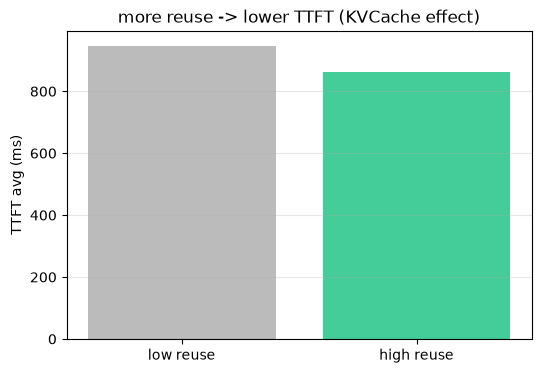

In [19]:
# 6-3. 저/고 재사용 데이터셋 프로파일 비교 (throttled)
r_low =run_aiperf("aiperf_low_reuse.jsonl",  request_count=6, prefix="low_reuse")
r_high=run_aiperf("aiperf_high_reuse.jsonl", request_count=6, prefix="high_reuse")
cols=("ttft_avg","ttft_p50","req_latency_avg","valid","errors")
cmp=pd.DataFrame([{"workload":"low reuse (f=0.0)", **{k:r_low.get(k) for k in cols}},
                  {"workload":"high reuse (f=0.9)",**{k:r_high.get(k) for k in cols}}])
display(cmp)

vals=[r_low["ttft_avg"], r_high["ttft_avg"]]
if all(v is not None for v in vals):
    plt.figure(figsize=(6,4))
    plt.bar(["low reuse","high reuse"],vals,color=["#bbb","#4c9"])
    plt.ylabel("TTFT avg (ms)"); plt.title("more reuse -> lower TTFT (KVCache effect)"); plt.grid(axis="y",alpha=.3); plt.show()
else:
    print("TTFT 누락(과부하/타임아웃)으로 막대그래프 생략. 위 표의 수치를 확인하세요.")

In [20]:
# 6-4. (선택) 실제 Kimi 512-블록 trace 를 네이티브로 리플레이
# Kimi trace 는 블록크기 512 라 aiperf mooncake_trace 가 그대로 읽습니다.
# 비용 절감을 위해 앞 N건 + 출력 길이를 줄여 저장.
src=load_trace(DATA/"kimi_conversation_trace.jsonl", limit=12)
with open("kimi_native_small.jsonl","w") as f:
    for r in src:
        f.write(json.dumps({"timestamp":r["timestamp"],"input_length":r["input_length"],
                            "output_length":min(int(r["output_length"]),16),
                            "hash_ids":r["hash_ids"]})+"\n")
r_kimi=run_aiperf("kimi_native_small.jsonl", model=MODEL_KIMI, request_count=6, prefix="kimi_native")
print({k:r_kimi.get(k) for k in ("ttft_avg","ttft_p50","req_latency_avg","valid","errors")})

>> aiperf kimi_native_small.jsonl (rc=6, rate=0.25/s)


23:33:06.020 INFO     Starting AIPerf System (_single_run.py:64)


23:33:06.360 INFO     Registered Worker Manager (id: 'worker_manager') (system_controller.py:387)
23:33:06.380 INFO     Server Metrics: Discovered 1 endpoints: ['https://serverless.tensormesh.ai/metrics'] (manager.py:74)
23:33:06.411 INFO     GPU telemetry export enabled: /home/hadry/lab/kcc2026-tutorial/artifacts/moonshotai_Kimi-K2.6-openai-chat/kimi_native_gpu_telemetry.jsonl (jsonl_writer.py:56)
23:33:06.460 INFO     Registered Dataset Manager (id: 'dataset_manager') (system_controller.py:387)
23:33:06.466 INFO     Telemetry streaming is disabled (set --otel-url and/or --mlflow-tracking-uri to enable) (otel_metrics_results_processor.py:128)
23:33:06.466 INFO     OTel metrics streamer is disabled and will not be used: Telemetry streaming is disabled (set --otel-url and/or --mlflow-tracking-uri to enable) (records_manager.py:206)
23:33:06.472 INFO     Record metrics export enabled: /home/hadry/lab/kcc2026-tutorial/artifacts/moonshotai_Kimi-K2.6-openai-chat/kimi_native.jsonl (record_ex

23:33:06.578 INFO     Registered Record Processor (id: 'record_processor_1467050e') (system_controller.py:387)
23:33:06.700 INFO     Registered Record Processor (id: 'record_processor_c22124fe') (system_controller.py:387)
23:33:06.722 INFO     Registered Records Manager (id: 'records_manager') (system_controller.py:387)
23:33:06.772 INFO     Registered Worker (id: 'worker_1f2eff96') (system_controller.py:387)


23:33:06.782 INFO     Registered Worker (id: 'worker_450acd08') (system_controller.py:387)
23:33:06.857 INFO     Registered Timing Manager (id: 'timing_manager') (system_controller.py:387)
23:33:06.859 INFO     Registered Worker (id: 'worker_386e64b4') (system_controller.py:387)
23:33:06.881 INFO     Registered Worker (id: 'worker_1b93312c') (system_controller.py:387)
23:33:06.908 INFO     Registered Worker (id: 'worker_99eaeecd') (system_controller.py:387)
23:33:06.909 INFO     Registered Worker (id: 'worker_952878e0') (system_controller.py:387)
23:33:06.933 INFO     Registered Worker (id: 'worker_6d6c9139') (system_controller.py:387)
23:33:06.934 INFO     Registered Worker (id: 'worker_43ff60a0') (system_controller.py:387)
23:33:06.936 INFO     Registered Worker (id: 'worker_e424f2e7') (system_controller.py:387)
23:33:06.937 INFO     Registered Worker (id: 'worker_9ebec63c') (system_controller.py:387)
23:33:06.938 INFO     Registered Worker (id: 'worker_4a9349b0') (system_controller.

...

23:33:08.240 INFO     Dataset client initialized and freed 12 conversations from memory (dataset_manager.py:185)
23:33:08.240 INFO     Dataset configured in 0.47 seconds (dataset_manager.py:156)
23:33:08.248 INFO     Server metrics disabled - no Prometheus endpoints reachable (system_controller.py:525)
23:33:08.248 INFO     All services configured in 0.89 seconds (system_controller.py:300)
23:33:08.248 INFO     AIPerf System is CONFIGURED (system_controller.py:278)
23:33:08.252 INFO     Creating interval generator: pattern=poisson, rate=0.25, smoothness=None (request_rate.py:114)
23:33:08.252 NOTICE   Phase profiling started | target: 6 requests, 120.0s duration (runner.py:369)
23:33:08.252 INFO     All services started profiling successfully (system_controller.py:322)
23:33:08.252 INFO     AIPerf System is PROFILING (system_controller.py:280)
23:33:08.252 INFO     Waiting for event 'profiling phase sending' with timeout of 119.999720589s (runner.py:744)
23:33:08.253 INFO     Credit ph

23:33:25.816 NOTICE   Phase profiling sending complete | sent=6, completed=5, in_flight=1 | sessions: sent=6, completed=5 (runner.py:608)
23:33:25.817 INFO     Waiting for event 'profiling phase credits returned' with timeout of 122.435408474s (runner.py:744)
23:33:25.817 INFO     Sent 6 requests. Waiting for all to complete... (records_manager.py:534)


23:33:27.709 NOTICE   Phase profiling complete | completed=6, cancelled=0, errors=0 | sessions: completed=6, cancelled=0 | elapsed=19.46s (runner.py:686)
23:33:27.709 NOTICE   All credits completed (phase_orchestrator.py:180)
23:33:27.710 INFO     Received credits complete from 'timing_manager' (system_controller.py:422)
23:33:27.710 INFO     Received CREDIT_PHASE_COMPLETE message, Phase complete: PhaseRecordsStats(phase=CreditPhase.PROFILING, start_ns=1781706788252381622, sent_end_ns=1781706805816545302, requests_end_ns=1781706807709374940, total_expected_requests=6, expected_duration_sec=None, expected_num_sessions=None, expected_grace_period_sec=None, final_requests_sent=None, final_requests_completed=6, final_requests_cancelled=0, final_request_errors=0, final_sent_sessions=None, final_completed_sessions=None, final_cancelled_sessions=None, timeout_triggered=False, grace_period_timeout_triggered=False, was_cancelled=False, records_end_ns=None, success_records=5, error_records=0) (r

23:33:29.709 INFO     Processing records results... (records_manager.py:777)
23:33:29.728 INFO     _finalize_and_process_results completed (records_manager.py:359)
23:33:29.729 INFO     All results received, initiating shutdown (system_controller.py:774)


23:33:30.331 INFO     Exporting all records (exporter_manager.py:62)
23:33:30.403 INFO     Exporting console data (exporter_manager.py:134)


                                    NVIDIA AIPerf | LLM Metrics                                     
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              Metric ┃      avg ┃      min ┃      max ┃      p99 ┃      p90 ┃      p50 ┃      std ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Time to First Token │ 2,244.72 │ 1,143.50 │ 3,650.62 │ 3,600.72 │ 3,151.63 │ 2,177.59 │   785.74 │
│                (ms) │          │          │          │          │          │          │          │
│      Time to Second │    19.25 │    15.58 │    23.69 │    23.64 │    23.16 │    18.51 │     3.11 │
│          Token (ms) │          │          │          │          │          │          │          │
│     Request Latency │ 3,189.22 │ 1,425.93 │ 5,38

## 7. 종합 분석 & 결론

### 무엇을 보았나
- **trace 분석**(2장): `hash_ids` 만으로 워크로드별 prefix 재사용을 정량화 — 코딩 trace 는 재사용이 높고, 대화/툴은 다른 패턴(논문 *KVCache in the Wild* 의 카테고리별 차이와 일치).
- **합성→주입**(3–5장): 같은 `hash_id`→같은 텍스트 매핑으로, 분석한 재사용 구조를 TensorMesh 에서 **실측 `cached_tokens`** 로 재현. 공유 prefix 가 커질수록 cached fraction↑, TTFT↓.
- **aiperf**(6장): API 만 노출된 TensorMesh 에서도 **TTFT/지연/처리량**으로 KVCache 효용을 객관 측정. 재사용이 높은 워크로드의 TTFT 가 낮아짐.

### 논문과의 연결
- **Mooncake**: prefill/decode 분리 + KVCache pool 로 prefix 재사용을 극대화 → 우리가 본 *cached_tokens>0 일 때 TTFT 급감* 이 그 prefill 절약의 직접 증거.
- **Trading Storage for Computation**: 캐시에 저장해두면 재계산을 건너뜀 → cached fraction 이 곧 절약한 prefill 연산량.
- **KVCache in the Wild**: 블록 인기도의 Zipf·reuse distance·카테고리 차이 → 2장 분석에서 동일 경향 관찰.

### 운영 메모
- 실측 `cached fraction` 은 목표 `f` 와 **비례하되 동일하진 않음**(단어↔토큰, 서버 블록 경계). 항상 실측을 함께 보세요.
- 공용 serverless 는 `429` 가 있으므로 **낮은 동시성 + backoff** 가 기본. 대규모 측정은 전용 배포에서.
- TensorMesh 콘솔의 **Cache Savings / Serverless Usage** 대시보드에서 누적 cache hit rate·비용 절감을 교차 확인할 수 있습니다.

### 더 해보기
- 2장 `TRACE_FILE` 을 바꿔 워크로드별 hit 곡선 비교
- 5장 파라메트릭 스윕을 `f` 더 촘촘히 / 요청 수 늘려 통계적으로
- 6장 `--concurrency` 를 2–4 로 올려 처리량-지연 트레이드오프와 429 빈도 관찰
